This notebook contains scripts needed for Fig1

files needed (located in the Fig1 directory):
 - Strains_Ranks_WithoutFreqs.csv (file with immunogenic epitopes with VOC mutations)
 - Delta_GISAID_beforeMHCpan_WithoutFreqs.csv (file with immunogenic epitopes with post-Delta individual mutations)
 - Omicron_GISAID_beforeMHCpan_WithoutFreqs.csv (file with immunogenic epitopes with post-Omicron individual mutations)

files needed (located in the same directory as the code):
 - Delta_gisaid_beforeMHCpan_WithoutFreqs.csv (file with immunogenic epitopes with post-Delta EVs)
 - Omicron_gisaid_beforeMHCpan_WithoutFreqs.csv (file with immunogenic epitopes with post-Omicron EVs)

folders needed:
  - country, state, city (files in those directories differ by the HLA frequency datasets used)
  - Fig1 (files with individual mutations instead of EVs)

In [1]:
import numpy as np
import pandas as pd
import re
import seaborn as sns
import matplotlib.pyplot as plt
import matplotlib.colors as pltcol
from scipy import stats
import math
from scipy.stats import mannwhitneyu
import glob
from matplotlib.colors import LinearSegmentedColormap
from collections import Counter
import collections
import cmasher as cmr
import glob

# Fig 1

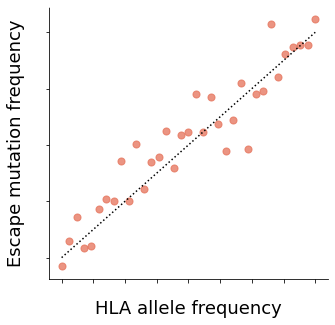

In [4]:
#for fig.1a
colors = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
palette = [colors[16]]

fig, ax = plt.subplots(figsize = (5,5))
x=np.linspace(0,20,35)  
y=np.random.normal(x, scale=2)
plt.scatter(x=x, y=y, s=50, alpha=0.75, c = palette)
ax.tick_params(axis = 'both', labelcolor='white')
plt.plot(x,x, color='black', linestyle = 'dotted')
ax.set_xlabel('HLA allele frequency'  , fontsize = 18)
ax.set_ylabel('Escape mutation frequency'  , fontsize = 18)
ax.spines['right'].set_color('white')
ax.spines['top'].set_color('white')
plt.savefig('Fig1/Scheme_correlation.jpg', dpi=300, bbox_inches='tight')

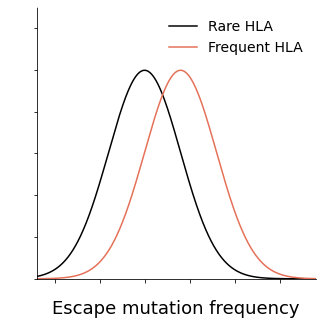

In [5]:
#for fig.1a

from scipy.stats import norm
fig, ax = plt.subplots(figsize = (5,5))
colors = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
x1 = np.arange(-15, 20, 0.001)
x2 = np.arange(-15, 5, 0.001)
# Mean = 0x1 SD = 2.
ax.plot(x1, norm.pdf(x1,0,4),color='black', label='Rare HLA')
ax.plot(x1, norm.pdf(x1,4,4),color=colors[16], label='Frequent HLA')
ax.legend(fontsize=14,loc = 'upper right',frameon=False)
ax.set_xlim(-12,19)
ax.set_ylim(0,0.13)
ax.tick_params(axis = 'both', labelcolor='white')
ax.set_xlabel('Escape mutation frequency', fontsize = 18)
ax.spines['right'].set_color('white')
ax.spines['top'].set_color('white')
plt.savefig('Fig1/Scheme_correlation2.jpg', dpi=300, bbox_inches='tight')

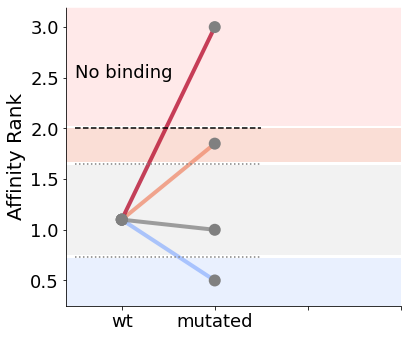

In [6]:
##for fig.1b
data = pd.DataFrame({'index':[0,1,2,3],'effect':['Lost binding', 'Decreased binding', 'Same binding', 'Increased binding'], 
                    'wt_Rank':[1.1,1.1,1.1,1.1], 'mut_Rank':[3, 1.85, 1,0.5]})
data = pd.melt(data, id_vars=['effect', 'index'])

colors_o = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
colors_outer = [colors_o[5], 'grey', colors_o[15],colors_o[19]]

fig, ax = plt.subplots(figsize = (6,5.5))
sns.stripplot(x="variable", y="value", data=data, ax=ax, size=12, alpha=1, jitter=0, color = 'grey')
sns.lineplot(data=data, x="variable", y="value", hue = 'effect',units='index', hue_order = ['Increased binding', 'Same binding', 
                                    'Decreased binding', 'Lost binding'],linewidth=4, palette = colors_outer, alpha=0.75, estimator=None, legend=False)


plt.plot([-0.5,1.5], [2,2], c = 'black', linestyle='--')
plt.plot([-0.5,1.5], [1.1*1.5,1.1*1.5], c = 'grey', linestyle='dotted')
plt.plot([-0.5,1.5], [1.1/1.5,1.1/1.5], c = 'grey', linestyle='dotted')
plt.text(-0.5, 2.5, 'No binding',fontsize=18)


colors_o = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
#colors_outer = [colors_o[5], 'lightgrey', colors_o[15],colors_o[19]]
plt.axhspan(2.02,3.2, facecolor='red', alpha=0.085)
plt.axhspan(1.1/1.5+0.015,1.1*1.5-0.015, facecolor='grey', alpha=0.1)

plt.axhspan(1.1*1.5+0.015,2, facecolor=colors_o[15], alpha=0.275)
plt.axhspan(0,1.1/1.5-0.015, facecolor=colors_o[5], alpha=0.2)

ax.set_xticks([0,1,2,3])
ax.set_xticklabels(['wt', 'mutated', '', ''], fontsize = 18) 

ax.set_ylabel('Affinity Rank', fontsize = 20) 
ax.set_xlabel('', size = 12) 
ax.tick_params(axis = 'both', labelsize=18)
#ax.legend(title='EV effect', fontsize = 18, title_fontsize=18)
ax.set_ylim(0.25,3.2) 
ax.spines['right'].set_color('white')
ax.spines['top'].set_color('white')
ticks = ['black', 'black', 'white', 'white', 'white', 'white', 'white', 'white']
#plt.show()
plt.savefig('Fig1/Fig1_sheme.jpg', dpi=300, bbox_inches='tight')

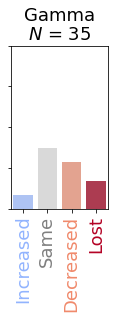

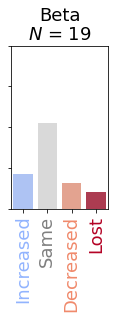

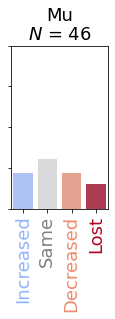

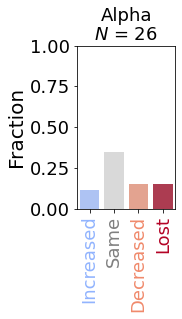

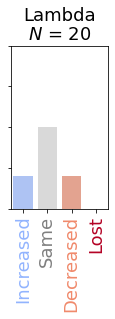

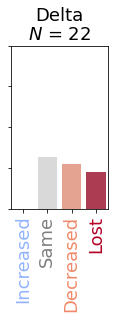

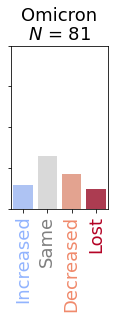

In [7]:
#for fig.1c
strains_t = pd.read_csv('Fig1/Strains_Ranks_WithoutFreqs.csv', index_col = False)
for strain in set(strains_t['strain']):
    table = strains_t[strains_t['strain'] == strain].replace('Other', 'Same')
    table_total = table[(table['mutations'] != 'wt')]
    data = table_total['EL_mark'].value_counts()/table_total.shape[0]
    fig, ax = plt.subplots(figsize = (1.75,3))
    df = pd.DataFrame(data.reset_index())
    colors_o = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
    colors_outer = [ colors_o[5], 'lightgrey', colors_o[15],colors_o[19]]

    sns.barplot(x='index', y='EL_mark', data=df, color='grey', alpha = 0.85, palette = colors_outer, 
                order = ['Increased binding', 'Same', 'Decreased binding', 'Lost binding'])

    plt.yticks(np.linspace(0, 1, 5), rotation=0, ha='right', fontsize = 18)
    ax.set_xticklabels(['Increased', 'Same', 'Decreased','Lost'],fontsize = 18, rotation = 90)
    #ax.set_yticklabels(['']+[*range(5, df['EL_mark'].max()+6, 5)], rotation=65, ha='center', fontsize = 13)
    plt.grid(axis='y', linestyle='--', alpha=0)
    plt.grid(axis='x', linestyle='--', alpha=0)
    #plt.title(strain[0].upper() + strain[1:] + '\n# mutations = '  + str(int(table_total.shape[0])), fontsize = 15)
    plt.text(1.5,1.15,strain[0].upper() + strain[1:], fontsize=18, horizontalalignment = 'center')
    plt.title('$\it{N}$'+ ' = '  + str(int(table_total.shape[0])), fontsize=18)

    #plt.rc('text', usetex=True)
    #plt.title(r'\fontsize{15pt}{3em}\selectfont{}{strain[0].upper() + strain[1:]\n}{\fontsize{12pt}{3em}\selectfont{}(mutations = str(int(table_total.shape[0]))}')
    colors_outer2 = [ colors_o[5], 'grey', colors_o[15],colors_o[19]]
    [t.set_color(colors_outer2[i]) for i,t in enumerate(ax.xaxis.get_ticklabels())]
    if strain == 'Alpha':
        #plt.xlabel('Number of mutations', fontsize = 15)
        plt.xlabel('', fontsize = 15)
        plt.ylabel('Fraction', fontsize = 20)
    else:
        ax.set_yticklabels([])
        plt.xlabel('', fontsize = 15)
        plt.ylabel('', fontsize = 15)
    plt.savefig('Fig1/Fig1_barplots' + strain+'.jpg', dpi=300, bbox_inches='tight')
    plt.show()

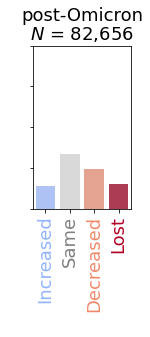

In [8]:
name = 'GISAID'
om_table = pd.read_csv('Fig1/Omicron_' + name + '_Ranks_WithoutFreqs.csv', index_col = False)
d_table = pd.read_csv('Fig1/Delta_' + name + '_Ranks_WithoutFreqs.csv', index_col = False)


table = om_table.copy()#change for Delta
table_total = table[(table['month'] == 'total')&(table['mutations'] != 'wt')].replace('Other', 'Same')

data = table_total['EL_mark'].value_counts()/table_total.shape[0]
fig, ax = plt.subplots(figsize = (1.75,3))
df = pd.DataFrame(data.reset_index())
colors_o = cmr.take_cmap_colors('coolwarm', 20, return_fmt='hex')
colors_outer = [colors_o[5], 'lightgrey', colors_o[15],colors_o[19]]

sns.barplot(x='index', y='EL_mark', data=df, color='grey', alpha = 0.85, palette = colors_outer, 
                order = ['Increased binding', 'Same', 'Decreased binding', 'Lost binding'])

plt.yticks(np.linspace(0, 1, 5), rotation=0, ha='right', fontsize = 18)
ax.set_xticklabels(['Increased', 'Same', 'Decreased','Lost'],fontsize = 18, rotation = 90)
#ax.set_yticklabels(['']+[*range(5, df['EL_mark'].max()+6, 5)], rotation=65, ha='center', fontsize = 13)
#plt.grid(axis='y', linestyle='--', alpha=0.5)
#plt.grid(axis='x', linestyle='--', alpha=0.5)   
    
    
plt.xlabel(' ', fontsize = 14)
plt.ylabel(' ', fontsize = 15)
colors_outer2 = [ colors_o[5], 'grey', colors_o[15],colors_o[19]]
[t.set_color(colors_outer2[i]) for i,t in enumerate(ax.xaxis.get_ticklabels())]
plt.text(1.5,1.15,'post-Omicron', fontsize=18, horizontalalignment = 'center')
plt.title('$\it{N}$'+ ' = '  + f'{table_total.shape[0]:,}', fontsize=18)
ax.set_yticklabels([])
plt.savefig('Fig1/Fig1_barplots' + 'post-Omicron' +'.jpg', dpi=300, bbox_inches='tight')
plt.show()

C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\2922753465.py:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wt_EL_Rank'] = np.log10(df['wt_EL_Rank'])
C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\2922753465.py:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mut_EL_Rank'] = np.log10(df['mut_EL_Rank'])
C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\2922753465.py:26: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklab

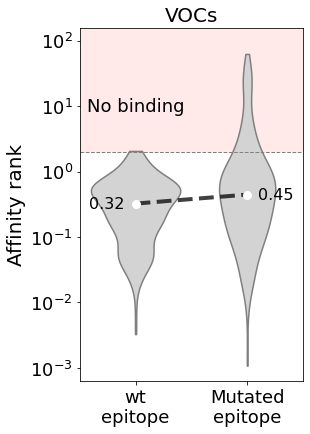

In [9]:
#for fig. 1d
strains_t = pd.read_csv('Fig1/Strains_Ranks_WithoutFreqs.csv', index_col = False)
table_total = strains_t[(strains_t['wt_EL_Rank'] <=2)]

df = table_total[['wt_EL_Rank', 'mut_EL_Rank']]
fig, ax = plt.subplots(figsize = (4,6.5))
ax.text(-0.1, np.log10(np.median(df['wt_EL_Rank'])),  '%.2f' %np.median(df['wt_EL_Rank']), fontsize=16, va="center", ha="right")
ax.text(0, 1, 'No binding', fontsize=18, va="center", ha="center")
ax.text(1.1,np.log10(np.median(df['mut_EL_Rank'])), '%.2f' %np.median(df['mut_EL_Rank']), fontsize=16, va="center", ha="left")
df['wt_EL_Rank'] = np.log10(df['wt_EL_Rank'])
df['mut_EL_Rank'] = np.log10(df['mut_EL_Rank'])
plt.axhspan(np.log10(2),3, facecolor='red', alpha=0.085)
sns.violinplot(data = df, color = 'lightgrey',cut=np.log10(2), inner = None, edgecolor='white')
plt.plot([-0.5, 1.5], [np.log10(2), np.log10(2)], linestyle='--', color = 'grey', lw=1)

medians = pd.DataFrame({'pos':['wt_EL_Rank', 'mut_EL_Rank'], 'medians':[np.median(df['wt_EL_Rank']),
                                                        np.median(df['mut_EL_Rank'])]})
sns.lineplot(x="pos", y='medians', data=medians, ax=ax,color = 'black',  alpha = 0.75, linestyle = '--', 
                    lw=4)
sns.stripplot(x="pos", y='medians', data=medians, ax=ax,color = 'white',  alpha = 1, size = 9, jitter=0)
U1, p = mannwhitneyu(table_total['wt_EL_Rank'], table_total['mut_EL_Rank'])
#barplot_annotate_brackets(0, 1, str('%.2e' %p), [0,1], [0.3, 0.3], dh=0.35,barh = 0.015, maxasterix=2, fs=12)

plt.ylabel('Affinity rank', fontsize = 20)
plt.title('VOCs', fontsize = 20)
ax.set_yticklabels(['$\mathregular{10^{-3}}$', '$\mathregular{10^{-3}}$', 
                    '$\mathregular{10^{-2}}$', '$\mathregular{10^{-1}}$', '$\mathregular{10^{0}}$', '$\mathregular{10^{1}}$', '$\mathregular{10^{2}}$'])

ax.set_ylim(-3.2,2.2)
plt.xticks([0,1], ha='right', fontsize = 18)
ax.set_xticklabels(['wt\nepitope','Mutated\nepitope'], ha='center', fontsize = 18)
#plt.grid(axis='y', linestyle='--', alpha=0.5)
#plt.grid(axis='x', linestyle='--', alpha=0.5)
ax.set_xlabel('')
ax.tick_params(axis = 'both', labelsize=18)#plt.grid(axis='y', linestyle='--', alpha=0.5)
#plt.grid(axis='x', linestyle='--', alpha=0.5)
plt.savefig('Fig1/Fig1_violins_mutations_' + 'VOCs' +'.jpg', dpi=300, bbox_inches='tight')

C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\845242004.py:13: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wt_EL_Rank'] = np.log10(df['wt_EL_Rank'])
C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\845242004.py:14: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mut_EL_Rank'] = np.log10(df['mut_EL_Rank'])
C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\845242004.py:33: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels

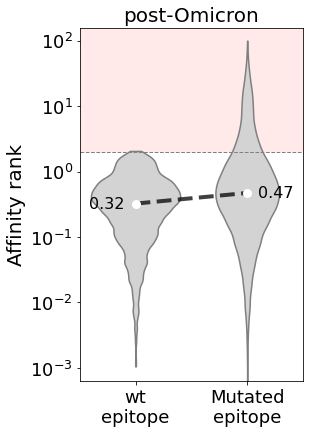

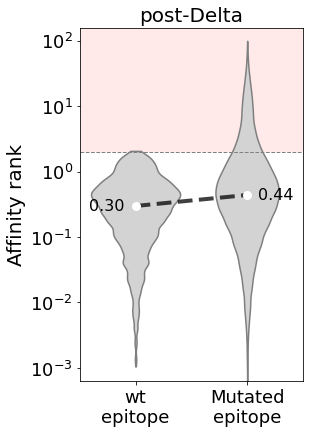

In [15]:
name = 'GISAID' # for individual mutations, see Final_0_files
for strain in ['Omicron', 'Delta']:
    table = pd.read_csv('Fig1/'+strain+'_' + name + '_Ranks_WithoutFreqs.csv', index_col = False)
    table_total = table[(table['month'] == 'total')&(table['mutations'] != 'wt')&(table['wt_EL_Rank']<=2)
                       ]
    table_total.head()

    df = table_total[['wt_EL_Rank', 'mut_EL_Rank']]
    fig, ax = plt.subplots(figsize = (4,6.5))
    ax.text(-0.1, np.log10(np.median(df['wt_EL_Rank'])),  '%.2f' %np.median(df['wt_EL_Rank']), fontsize=16, va="center", ha="right")
    #ax.text(0, 1, 'No binding', fontsize=18, va="center", ha="center")
    ax.text(1.1,np.log10(np.median(df['mut_EL_Rank'])), '%.2f' %np.median(df['mut_EL_Rank']), fontsize=16, va="center", ha="left")
    df['wt_EL_Rank'] = np.log10(df['wt_EL_Rank'])
    df['mut_EL_Rank'] = np.log10(df['mut_EL_Rank'])
    plt.axhspan(np.log10(2),3, facecolor='red', alpha=0.085)

    sns.violinplot(data = df, color = 'lightgrey',cut=np.log10(2), inner = None, edgecolor='lightgrey')
    plt.plot([-0.5, 1.5], [np.log10(2), np.log10(2)], linestyle='--', color = 'grey', lw=1)

    medians = pd.DataFrame({'pos':['wt_EL_Rank', 'mut_EL_Rank'], 'medians':[np.median(df['wt_EL_Rank']),
                                                            np.median(df['mut_EL_Rank'])]})
    sns.lineplot(x="pos", y='medians', data=medians, ax=ax,color = 'black',  alpha = 0.75, linestyle = '--', 
                        lw=4)
    sns.stripplot(x="pos", y='medians', data=medians, ax=ax,color = 'white',  alpha = 1, size = 9, jitter=0)
    U1, p = mannwhitneyu(table_total['wt_EL_Rank'], table_total['mut_EL_Rank'])
    #barplot_annotate_brackets(0, 1, str('%.2e' %p), [0,1], [0.3, 0.3], dh=0.35,barh = 0.015, maxasterix=2, fs=12)

    plt.ylabel('Affinity rank', fontsize = 20)
    plt.title('post-'+strain, fontsize = 20)
    ax.set_ylim(-3.2,2.2)
    plt.xticks([0,1], ha='right', fontsize = 18)
    ax.set_xticklabels(['wt\nepitope','Mutated\nepitope'], ha='center', fontsize = 18)
    ax.set_yticklabels(['$\mathregular{10^{-3}}$', '$\mathregular{10^{-3}}$', 
                        '$\mathregular{10^{-2}}$', '$\mathregular{10^{-1}}$', '$\mathregular{10^{0}}$', '$\mathregular{10^{1}}$', '$\mathregular{10^{2}}$'])

    ax.set_xlabel('')
    ax.tick_params(axis = 'both', labelsize=18)

    plt.savefig('Fig1/Fig1_violins_mutations_' + 'post-'+strain +'.jpg', dpi=300, bbox_inches='tight')

C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\628546206.py:15: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['wt_EL_Rank'] = np.log10(df['wt_EL_Rank'])
C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\628546206.py:16: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['mut_EL_Rank'] = np.log10(df['mut_EL_Rank'])
C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\628546206.py:35: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels

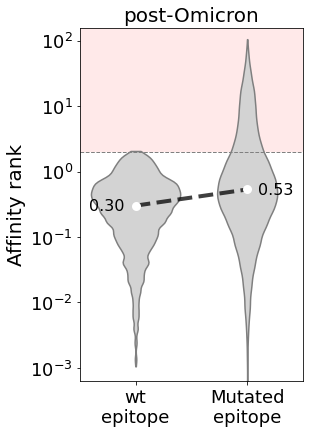

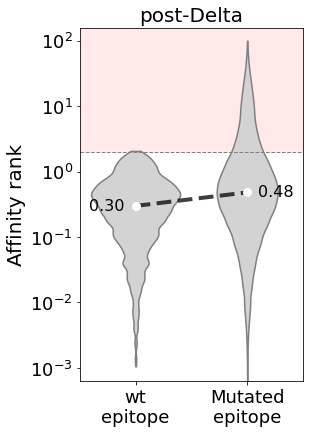

In [16]:
#for fig. 1e
name = 'gisaid' # for EVs mutations, see Final_0_files

for strain in ['Omicron', 'Delta']:
    table = pd.read_csv(strain + '_' + name + '_Ranks_WithoutFreqs.csv', index_col = False)
    table_total = table[(table['month'] == 'total')&(table['mutations'] != 'wt')&(table['wt_EL_Rank']<=2)
                       ]
    table_total.head()

    df = table_total[['wt_EL_Rank', 'mut_EL_Rank']]
    fig, ax = plt.subplots(figsize = (4,6.5))
    ax.text(-0.1, np.log10(np.median(df['wt_EL_Rank'])),  '%.2f' %np.median(df['wt_EL_Rank']), fontsize=16, va="center", ha="right")
    #ax.text(0, 1, 'No binding', fontsize=18, va="center", ha="center")
    ax.text(1.1,np.log10(np.median(df['mut_EL_Rank'])), '%.2f' %np.median(df['mut_EL_Rank']), fontsize=16, va="center", ha="left")
    df['wt_EL_Rank'] = np.log10(df['wt_EL_Rank'])
    df['mut_EL_Rank'] = np.log10(df['mut_EL_Rank'])
    plt.axhspan(np.log10(2),3, facecolor='red', alpha=0.085)

    sns.violinplot(data = df, color = 'lightgrey',cut=np.log10(2), inner = None, edgecolor='lightgrey')
    plt.plot([-0.5, 1.5], [np.log10(2), np.log10(2)], linestyle='--', color = 'grey', lw=1)

    medians = pd.DataFrame({'pos':['wt_EL_Rank', 'mut_EL_Rank'], 'medians':[np.median(df['wt_EL_Rank']),
                                                            np.median(df['mut_EL_Rank'])]})
    sns.lineplot(x="pos", y='medians', data=medians, ax=ax,color = 'black',  alpha = 0.75, linestyle = '--', 
                        lw=4)
    sns.stripplot(x="pos", y='medians', data=medians, ax=ax,color = 'white',  alpha = 1, size = 9, jitter=0)
    U1, p = mannwhitneyu(table_total['wt_EL_Rank'], table_total['mut_EL_Rank'])
    #barplot_annotate_brackets(0, 1, str('%.2e' %p), [0,1], [0.3, 0.3], dh=0.35,barh = 0.015, maxasterix=2, fs=12)

    plt.ylabel('Affinity rank', fontsize = 20)
    plt.title('post-'+strain, fontsize = 20)
    ax.set_ylim(-3.2,2.2)
    plt.xticks([0,1], ha='right', fontsize = 18)
    ax.set_xticklabels(['wt\nepitope','Mutated\nepitope'], ha='center', fontsize = 18)
    ax.set_yticklabels(['$\mathregular{10^{-3}}$', '$\mathregular{10^{-3}}$', 
                        '$\mathregular{10^{-2}}$', '$\mathregular{10^{-1}}$', '$\mathregular{10^{0}}$', '$\mathregular{10^{1}}$', '$\mathregular{10^{2}}$'])

    ax.set_xlabel('')
    ax.tick_params(axis = 'both', labelsize=18)

    plt.savefig('Fig1/Fig1_violins_Evs_' + 'post-'+strain +'.jpg', dpi=300, bbox_inches='tight')

### For fig1f

In [ ]:
#3 next cells should be repeated for BA1 and BA2
#get mutation frequencies
#part1

import sys
#import ete3
#from ete3 import Tree
#import random
import re
import itertools
#import optparse
from collections import defaultdict

#parser=optparse.OptionParser()
#parser.add_option('-l', '--lineage', help='', type='str')
#options, args=parser.parse_args()

#clade = options.lineage

gisaid_month_samples = defaultdict(int)
with open('GISAID.paths.tsv') as f:
    for line in f:
        sample = line.split("\t")[0]
    
        ym = "no_date"
        elements = sample.split("|")
        if len(elements) > 2:
            date = elements[2]
            subdates = date.split("-")
            if len(subdates) > 1:
                year = subdates[0]
                month = subdates[1]
                if len(month) == 1:
                    month = "0"+month
                ym = str(year)+"-"+str(month)
                gisaid_month_samples[ym] += 1
                
                
delta_month_samples = defaultdict(int)
with open('B.1.617.2.paths.tsv') as f:
    for line in f:
        sample = line.split("\t")[0]

        ym = "no_date"
        elements = sample.split("|")
        if len(elements) > 2:
            date = elements[2]
            subdates = date.split("-")
            if len(subdates) > 1:
                year = subdates[0]
                month = subdates[1]
                ym = str(year)+"-"+str(month)
                delta_month_samples[ym] += 1

ba1_month_samples = defaultdict(int)
with open('BA.1.paths.tsv') as f:
    for line in f:
        sample = line.split("\t")[0]

        ym = "no_date"
        elements = sample.split("|")
        if len(elements) > 2:
            date = elements[2]
            subdates = date.split("-")
            if len(subdates) > 1:
                year = subdates[0]
                month = subdates[1]
                ym = str(year)+"-"+str(month)
                ba1_month_samples[ym] += 1

ba2_month_samples = defaultdict(int)
with open('BA.2.paths.tsv') as f:
    for line in f:
        sample = line.split("\t")[0]

        ym = "no_date"
        elements = sample.split("|")
        if len(elements) > 2:
            date = elements[2]
            subdates = date.split("-")
            if len(subdates) > 1:
                year = subdates[0]
                month = subdates[1]
                ym = str(year)+"-"+str(month)
                ba2_month_samples[ym] += 1

outfile = open("MonthsLineagesFrequenceis.fromUShER.tsv","w")
outfile.write("month\tgisaid\tdelta\tba1\tba2\n")
for month in sorted(gisaid_month_samples):
    gisaid_samp = gisaid_month_samples[month]
    
    delta_samp = 0
    if month in delta_month_samples:
        delta_samp = delta_month_samples[month]
    
    ba1_samp = 0
    if month in ba1_month_samples:
        ba1_samp = ba1_month_samples[month]
        
    ba2_samp = 0
    if month in ba2_month_samples:
        ba2_samp = ba2_month_samples[month]

    outfile.write(str(month)+"\t"+str(gisaid_samp)+"\t"+str(delta_samp)+"\t"+str(ba1_samp)+"\t"+str(ba2_samp)+"\n")

outfile.close()

In [ ]:
#part2
import re
import statistics
import optparse
from collections import defaultdict
import itertools
import random
import copy
import sys

parser=optparse.OptionParser()
parser.add_option('-p', '--paths', help='', type='str')
#parser.add_option('-t', '--town', help='', type='str')
options, args=parser.parse_args()

paths = options.paths
voc_lineage = paths.replace(".paths.tsv","")

month_samples = dict()
with open("MonthsLineagesFrequenceis.fromUShER.tsv") as freq_file: #obtained in part1
    header = freq_file.readline()
    for line in freq_file:
        line = line.rstrip()
        month = line.split("\t")[0]
        samples =  line.split("\t")[1]
        month_samples[month] = samples
#        print(line)
#        print(type(samples))
#        print(str(month))
#        print(str(samples))
#        sys.exit()


prot_begin_end_seq_lost = defaultdict(lambda: defaultdict(list))
prot_begin_end_seq_enhanced = defaultdict(lambda: defaultdict(list))
prot_beg_ends = defaultdict(list)        
with open("delta_gisaid_epitops_mut.csv") as pept_file: #for BA1 and BA2 use omicron_gisaid_epitops_mut.csv
    line1 = pept_file.readline()
    for line in pept_file:
        line = line.rstrip()
        inf = line.split(",")
        pr = inf[0]
        if pr !="":
            #print(line)
            begin = inf[1]
            end = inf[2]
            #begin = begin.replace(".0","")
            #begin = int(begin)
            #end = end.replace(".0","")
            #end = int(end)
            begin_end = begin+"_"+end
            seq = inf[3]
            effect = inf[6]

            if effect == "Increased binding" and seq not in prot_begin_end_seq_enhanced[pr][begin_end]:
                prot_begin_end_seq_enhanced[pr][begin_end].append(seq)
                if begin_end not in prot_beg_ends[pr]:
                    prot_beg_ends[pr].append(begin_end)
            elif effect == "Lost binding" and seq not in prot_begin_end_seq_lost[pr][begin_end]:
                prot_begin_end_seq_lost[pr][begin_end].append(seq)
                if begin_end not in prot_beg_ends[pr]:
                    prot_beg_ends[pr].append(begin_end)


codon_aa = dict()
with open("genetic_code") as codon_table:
    for line in codon_table:
        codon = line.split(" ")[0]
        aa = line.split(" ")[1]
        codon_aa[codon] = aa

#prot_begins = ["266","806","2720","8555","10055","10973","11843","12092","12686","13025","16237","18040","19621","20659","21563","25393","26245","26523","27202","27394","27756","27894","28274","29558"]
#prot_begins = [eval(i) for i in prot_begins]

#prot_ends = ["805","2719","8554","10054","10972","11842","12091","12685","13024","13441","18039","19620","20658","21552","25384","26220","26472","27191","27387","27759","27887","28259","29533","29674"]
#prot_ends = [eval(i) for i in prot_ends]

#prot_names = ["leader","nsp2","nsp3","nsp4","3C","nsp6","nsp7","nsp8","nsp9","nsp10","helicase","exonuclease","endornase","methyltransferase","Spike","ORF3a","E","M","ORF6","ORF7a","ORF7b","ORF8","N","ORF10"]

protpos_ref = dict()
ref_file = open('/gss/home/e.riumina/Galya_Guest/ReferenceWuhan.one_line.fasta', 'r') #ReferenceWuhan.one_line.fasta is in the main direcroty
firstLine = ref_file.readline()
refseq = ref_file.readline().rstrip()
for k in range(1,len(refseq)+1):
    nt = refseq[(k-1)]
    k = int(k)
    protpos_ref[k] = nt

prot_begins = dict()
prot_ends = dict()

with open("CoV.prot_regions.Pond.txt") as coords:
    line1 = coords.readline()
    for line in coords:
        line = line.rstrip()
        #print(line)
        prot = line.split("\t")[0]
        begin = int(line.split("\t")[1])
        end = int(line.split("\t")[2])
        prot_begins[prot] = begin
        prot_ends[prot] = end
#        print(prot+"\t"+str(begin)+"\t"+str(end))


#countries = ["Argentina","Armenia","Austria","Brazil","Chile","China","Colombia","Croatia","CzechRepublic","France","Germany","Greece","Iran","Iraq","Ireland","NorthernIreland","Italy","Japan","Jordan","South Korea","Malaysia","Mexico","Netherlands","Nigeria","Norway","Poland","Portugal","Romania","Russia","Slovakia","Spain","SriLanka","Sweden","Switzerland","Thailand","Turkey","UnitedArabEmirates","Israel"]

#month_enhanced_fractions = defaultdict(list)
#month_lost_fractions = defaultdict(list)
#month_mutated_fractions = defaultdict(list)
#month_enhanced_epitops = defaultdict(list)
month_covered_epitops = defaultdict(int)
month_lost_epitops = defaultdict(lambda: defaultdict(int))
with open(options.paths) as mut_file:
    for line in mut_file:
        protpos_nt = copy.deepcopy(protpos_ref)
        line = line.rstrip()
        sample = line.split("\t")[0]

        country = sample.split("/")[0]
        country = country.replace(" ","")
        country = country.replace("_","")

        #print("sample: "+sample)
        nds = line.split("\t")[1]
        all_nodes = nds.split(" ")
        #site_waiting_muts = dict()
        for i in range(0,len(all_nodes)):
            string = all_nodes[i]
            node = string.split(":")[0]
            muts = string.split(":")[1]
            each_mut = muts.split(",")

            for mut in each_mut:
                prev_let = mut[0]
                new_let = mut[len(mut)-1]
                site = mut[1:(len(mut)-1)]
                site = int(site)

                #print(str(site))
                current_let = protpos_nt[site]

                if current_let != prev_let:
                    print (string)
                    print (str(current_let)+"\t"+str(prev_let)+"\t"+str(new_let))
                    sys.exit()

                if new_let != current_let:
                    protpos_nt[site] = new_let
                    #print (sample)
                    #print(mut)
                    #sys.exit()
                    


        fasta_seq = str()
        for site in sorted(protpos_nt):
            current_nt = protpos_nt[site]
             #current_aa = codon_aa[current_codon]
            fasta_seq = fasta_seq + current_nt

        ym = "no_date"
        elements = sample.split("|")
        if len(elements) > 2:
            date = elements[2]
            subdates = date.split("-")
            if len(subdates) > 1:
                year = subdates[0]
                month = subdates[1]
                ym = str(year)+"-"+str(month)
            
                covered_ep = 0
                mutated_ep = 0
                enhanced_ep = 0
                lost_ep = 0
                
                for protein in prot_begins:
                    begin_end_seq_enhanced = prot_begin_end_seq_enhanced[protein]
                    begin_end_seq_lost = prot_begin_end_seq_lost[protein]
                    beg_ends = prot_beg_ends[protein]
                    prot = ""
                    
                    if protein != "RdRp":
                        prot_begin = prot_begins[protein]
                        prot_end = prot_ends[protein]

                        gene = fasta_seq[(prot_begin-1):prot_end]

                        for i in range(0,(len(gene)-2),3):
                            codon = gene[i:(i+3)]
                            if codon in codon_aa:
                                aa = codon_aa[codon]
                                prot = prot+aa
                            else:
                                prot = prot+"-"

                    elif protein == "RdRp":
                        begin1 = prot_begins["RdRp1"]
                        end1  = prot_ends["RdRp1"]
                        begin2 =  prot_begins["RdRp2"]
                        end2  = prot_ends["RdRp1"]

                        gene1 = fasta_seq[(begin1-1):end1]
                        for i in range(0,(len(gene1)-2),3):
                            codon = gene1[i:(i+3)]
                            if codon in codon_aa:
                                aa = codon_aa[codon]
                                prot = prot+aa
                            else:
                                prot = prot+"-"

                        gene2 = fasta_seq[(begin2-1):end2]
                        for i in range(0,(len(gene2)-2),3):
                            codon = gene2[i:(i+3)]
                            if codon in codon_aa:
                                aa = codon_aa[codon]
                                prot = prot+aa
                            else:
                                prot = prot+"-"

                    for beg_end in beg_ends:
                        beg = int(beg_end.split("_")[0])
                        end = int(beg_end.split("_")[1])
                        seq_pept = prot[(beg-1):end]
                        peptide = beg_end+"_"+seq_pept
                        #ym_beg_end = ym+"_"+beg_end
                        if "-" not in seq_pept:
                            #month_covered_epitops[ym_beg_end] += 1
                            #if beg_end in begin_end_seq_enhanced:
                            #    for seq_mut in begin_end_seq_enhanced[beg_end]:
                            #        if seq_pept == seq_mut:
                            #            enhanced_ep += 1

                            if beg_end in begin_end_seq_lost:
                                for seq_mut in begin_end_seq_lost[beg_end]:
                                    if seq_pept == seq_mut:
                                        month_lost_epitops[ym][peptide] += 1
                                        
               

peptide_total = defaultdict(int)
samples_total = 0
outfile = open("DeltaMuts.FromUsher.LostEpitopesFreq.tsv","w")
outfile.write("month"+"\t"+"beg_end_seq"+"\t"+"seqs"+"\t"+"all"+"\t"+"freq"+"\n")
for month in month_samples:
    samples = int(month_samples[month])
    samples_total += samples
    if month in month_lost_epitops:
        peptides = month_lost_epitops[month]
        for pept in peptides:
            lost = month_lost_epitops[month][pept]
            peptide_total[pept] += lost
            freq = lost/samples
            outfile.write(month+"\t"+pept+"\t"+str(lost)+"\t"+str(samples)+"\t"+str(freq)+"\n")
outfile.close()

top_freqs = dict()
#other_freq = 0
for pept in peptide_total:
    freq = peptide_total[pept]/samples_total
    if freq > 0.05:
        top_freqs[pept] = freq
#    else:
#        other_freq += freq
sorted_top= sorted(top_freqs.items(), key=lambda x:x[1], reverse=True)
top_freqs = dict(sorted_top)
top_list = list(top_freqs.keys())

outfile1 = open("DeltaMuts.FromUsher.LostEpitopesFreq.RareCollapsed.tsv","w")
outfile1.write("month"+"\t"+"beg_end_seq"+"\t"+"seqs"+"\t"+"all"+"\t"+"freq"+"\n")
for month in month_samples:
    samples = int(month_samples[month])
    #samples_total += samples
    if month in month_lost_epitops:
        peptides = month_lost_epitops[month]
        cumulative_lost = 0
        for top in top_list:
            if top in peptides:
                lost = month_lost_epitops[month][pept]
                lost = lost+cumulative_lost
                cumulative_lost = lost
                freq = lost/samples
                outfile1.write(month+"\t"+pept+"\t"+str(lost)+"\t"+str(samples)+"\t"+str(freq)+"\n")

        for pept in peptides:
            if pept not in top_list:
                lost = month_lost_epitops[month][pept]
                cumulative_lost = cumulative_lost + lost
        other_freq = cumulative_lost/samples
        outfile1.write(month+"\t"+"other"+"\t"+str(cumulative_lost)+"\t"+str(samples)+"\t"+str(other_freq)+"\n")
outfile1.close()

In [ ]:
#part3
import re
import statistics
import optparse
from collections import defaultdict
import itertools
import random
import copy
import sys

#parser=optparse.OptionParser()
#parser.add_option('-p', '--paths', help='', type='str')
#parser.add_option('-t', '--town', help='', type='str')
#options, args=parser.parse_args()

#paths = options.paths
#voc_lineage = paths.replace(".paths.tsv","")

month_samples = dict()
with open("MonthsLineagesFrequenceis.fromUShER.tsv") as freq_file:#obtained in part1
    header = freq_file.readline()
    for line in freq_file:
        line = line.rstrip()
        month = line.split("\t")[0]
        samples =  line.split("\t")[2]   #month gisaid delta ba1 ba2
        month_samples[month] = samples
#        print(line)
#        print(type(samples))
#        print(str(month))
#        print(str(samples))
#        sys.exit()



#peptide_total = defaultdict(int)
max_freqs = defaultdict(float)
top_list = list()
month_lost_epitops = defaultdict(dict)
with open("DeltaMuts.FromUsher.LostEpitopesFreq.tsv") as infile:#obtained in part2
#outfile.write("month"+"\t"+"beg_end_seq"+"\t"+"seqs"+"\t"+"all"+"\t"+"freq"+"\n")
    line1 = infile.readline()
    for line in infile:
        all_inf = line.split("\t")
        month = all_inf[0]
        pept = all_inf[1]
        mut_seqs = all_inf[2]
        all_seqs = month_samples[month]
        freq = int(mut_seqs)/int(all_seqs)
        if freq > float(max_freqs[pept]):
            max_freqs[pept] = freq
            
        if freq > 0.01 and pept not in top_list:
            top_list.append(pept)
 #           print(pept+"\t"+freq)

        month_lost_epitops[month][pept] = int(mut_seqs)
        #peptide_total[pept] += int(mut_seqs)
        
#for top in top_list:
#    print(top)
#sys.exit()

outfile_freqs = open("DeltaMuts.Pept_MaxFreq.LineageZnam.tsv","w")
outfile_freqs.write("pept\tfreq\n")
for pept in  max_freqs:
    outfile_freqs.write(pept+"\t"+str(max_freqs[pept])+"\n")
outfile_freqs.close()



pept_number = 0
outfile1 = open("DeltaMuts_FromUsher_LostEpitopesFreq_RareCollapsed_NotCumulative_LineageZnam.tsv","w")
outfile1.write("count"+"\t"+"month"+"\t"+"beg_end_seq"+"\t"+"seqs"+"\t"+"all"+"\t"+"freq"+"\n")
for month in month_samples:
    samples = int(month_samples[month])
    #samples_total += samples
    k = 0
    if month in month_lost_epitops:
        peptides = month_lost_epitops[month]
        cumulative_lost = 0
        for top in top_list:
            k = k+1
            if top in peptides:
                lost = month_lost_epitops[month][top]
                #lost = lost+cumulative_lost
                #cumulative_lost = lost
                if samples > 50:
                    freq = lost/samples
                    outfile1.write(str(k)+"\t"+month+"\t"+top+"\t"+str(lost)+"\t"+str(samples)+"\t"+str(freq)+"\n")

        k = k+1
        for pept in peptides:
            if pept not in top_list:
                pept_number += 1
                lost = month_lost_epitops[month][pept]
                cumulative_lost = cumulative_lost + lost
        if samples > 50:
            other_freq = cumulative_lost/samples
            outfile1.write(str(k)+"\t"+month+"\t"+"other"+"\t"+str(cumulative_lost)+"\t"+str(samples)+"\t"+str(other_freq)+"\n")
outfile1.close()
        
        
print(pept_number)

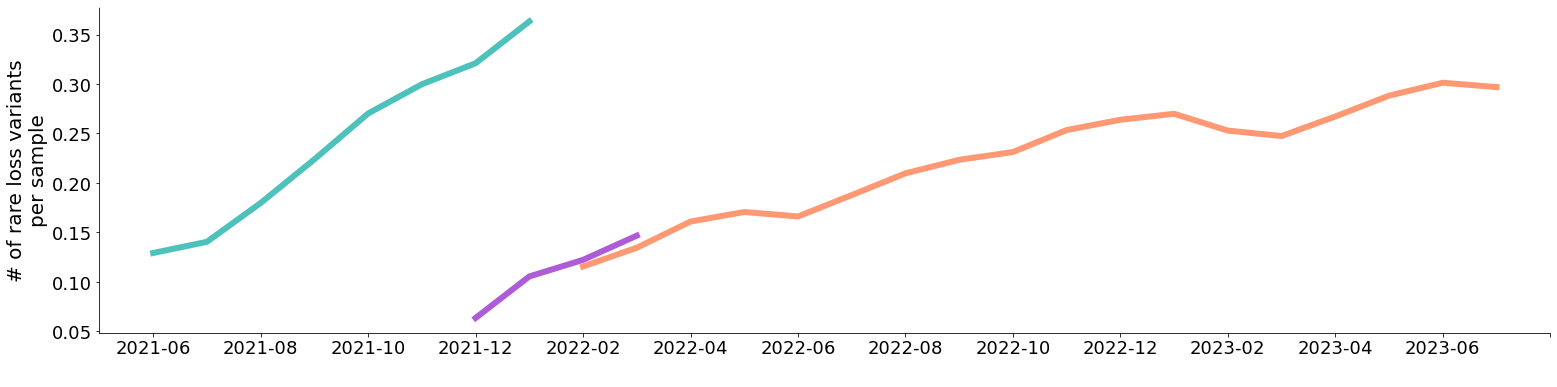

In [12]:
#now draw
ba1 = pd.read_csv('BA1Muts_FromUsher_LostEpitopesFreq_RareCollapsed_NotCumulative_LineageZnam.tsv', sep = '\t')
ba1 = ba1[ba1['beg_end_seq'] == 'other']
ba1['strain']  = 'BA1'
ba2 = pd.read_csv('BA2Muts_FromUsher_LostEpitopesFreq_RareCollapsed_NotCumulative_LineageZnam.tsv', sep = '\t')
ba2 = ba2[ba2['beg_end_seq'] == 'other']
ba2['strain']  = 'BA2'
d = pd.read_csv('DeltaMuts_FromUsher_LostEpitopesFreq_RareCollapsed_NotCumulative_LineageZnam.tsv', sep = '\t')
d = d[d['beg_end_seq'] == 'other']
d['strain']  = 'Delta'
all_strains = pd.concat([ba1, ba2, d]).reset_index()
all_strains = all_strains[all_strains['seqs']>=10000].sort_values('month')

fig, ax = plt.subplots(figsize = (26,6))
a = sns.lineplot(x = 'month', y = 'freq', hue = 'strain',data = all_strains,palette = ['lightseagreen', 'darkorchid', 'coral'],alpha = 0.8, ci = None,ax = ax, linewidth = 6, legend = False)
ax.set_xticks(np.arange(0, all_strains.shape[0]-1, 2))
ax.set_ylabel('# of rare loss variants\nper sample', fontsize = 20)
ax.set_xlabel(' ', fontsize = 18)
ax.tick_params(axis = 'both', labelsize=18)
ax.set_xlim(-1,26)
ax.spines['right'].set_color('white')
ax.spines['top'].set_color('white')
plt.savefig('Fig1/Apocalypsis_1.jpg', dpi=300, bbox_inches='tight')

C:\Users\Lenovo ThinkPad\AppData\Local\Temp\ipykernel_15424\3048749169.py:39: UserWarning: FixedFormatter should only be used together with FixedLocator
  ax.set_yticklabels(['0', '50,000', '100,000','150,000', '200,000', '250,000'])


[Text(0, 0.0, '0'),
 Text(0, 50000.0, '50,000'),
 Text(0, 100000.0, '100,000'),
 Text(0, 150000.0, '150,000'),
 Text(0, 200000.0, '200,000'),
 Text(0, 250000.0, '250,000'),
 Text(0, 300000.0, '')]

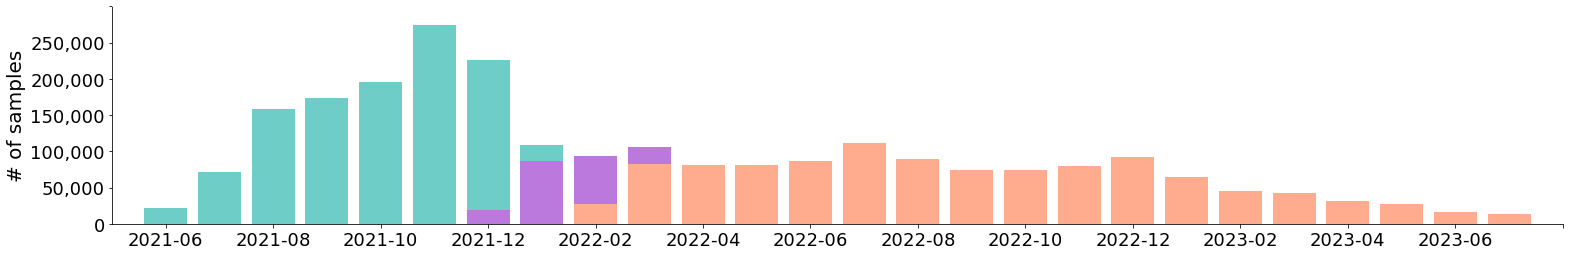

In [13]:
stacked_data = all_strains.pivot_table(
    index='month', 
    columns='strain', 
    values='seqs', 
    aggfunc='sum'
).fillna(0)
stacked_data = stacked_data[['Delta', 'BA1', 'BA2']] 

x = np.arange(len(stacked_data.index))

# Plot the bars
fig, ax = plt.subplots(figsize = (26,4))
bottom = np.zeros(len(x))  # Initialize bottom for stacking

colors = ['lightseagreen', 'darkorchid', 'coral'][::-1]  # Match categories
for i, column in enumerate(stacked_data.columns[::-1]):
    ax.bar(
        x, 
        stacked_data[column], 
        bottom=bottom, 
        label=column, 
        color=colors[i], 
        alpha=0.65
    )
    bottom += stacked_data[column]  # Update bottom for the next category

# Customizing the plot
ax.set_xticks(x)
ax.set_xticklabels(stacked_data.index, fontsize=12)
ax.set_xlim(-1,26)
ax.set_ylim(0,300000)
ax.set_xticks(np.arange(0, all_strains.shape[0]-2, 2))
ax.tick_params(axis = 'both', labelsize=18)
ax.set_ylabel('# of samples', fontsize = 20)
ax.set_xlabel(' ', fontsize = 18)
#ax.legend(fontsize=14,loc = 'upper right',frameon=False)
ax.spines['right'].set_color('white')
ax.spines['top'].set_color('white')
ax.set_yticklabels(['0', '50,000', '100,000','150,000', '200,000', '250,000'])
#plt.savefig('Fig1/Apocalypsis_2_stacked.jpg', dpi=300, bbox_inches='tight')